### Вводные данные

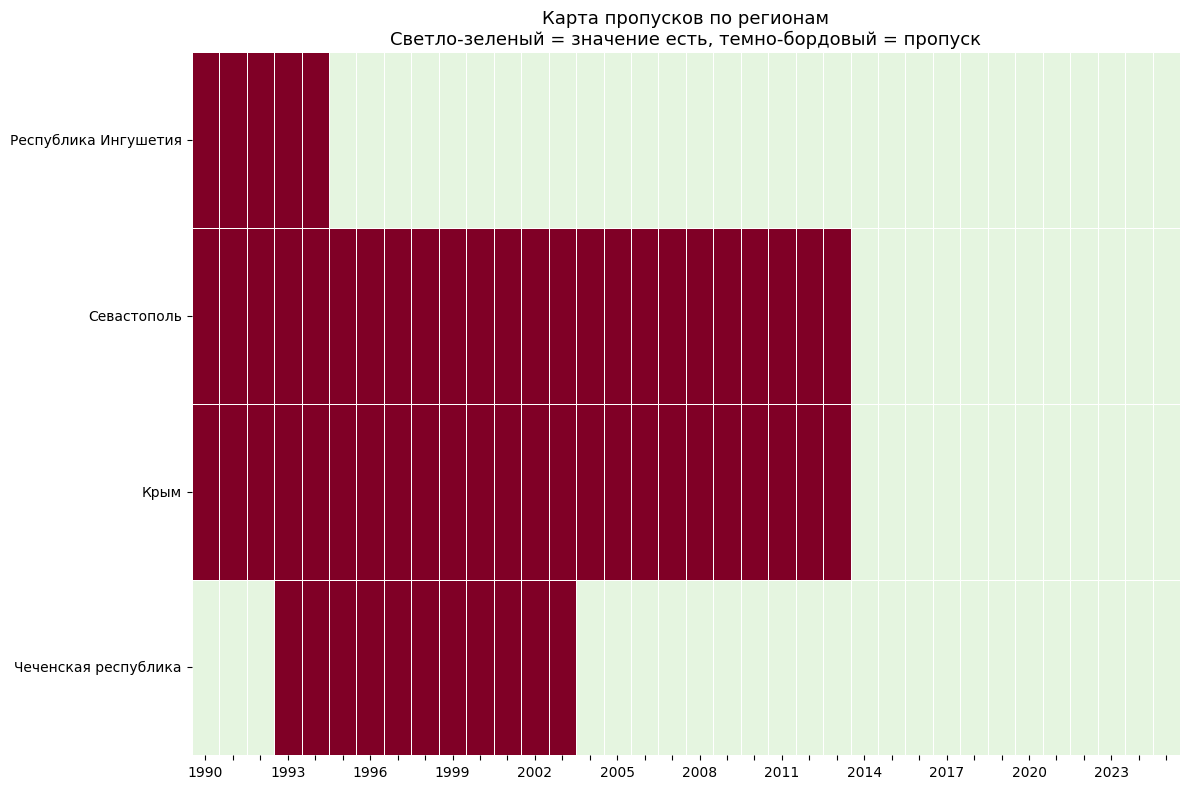

In [2]:
import stage2_base_funcs as base_funcs
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

file_path = 'путь до моего файла с данными'
sheets = base_funcs.load_sheets(file_path)

# Подгрузка нужной вкладки
df = sheets['СКР']

# Переводим в long формат
df_long = base_funcs.transform_to_long(df)

# Удаляем проблемные регионы
regions_to_exclude = ['Севастополь', 'Крым']
df_long = df_long[~df_long["Регион"].isin(regions_to_exclude)]

# Визуализация карты пропусков
base_funcs.analyze_missing_data(df, region_col='Регион')

### Определяем фазы перехода (Что-то такое должно быть!)

В оригинальной методологии ООН переход в Фазу III фиксируется при отсутствии снижения СКР на протяжении двух последовательных 5-летних периодов. Однако прямое применение этого критерия в рамках данного исследования невозможно по двум причинам:

**Размерность данных:** Используется панель годовых, а не пятилетних данных, что требует более высокой гранулярности при поиске точки перегиба тренда.  

**Ограниченность временного ряда:** Доступный горизонт (с 1990 по 2025 гг.) отсекает начальные этапы демографического перехода, а агрегация по 5 лет приведет к потере структурных сдвигов, вызванных введением федерального (2007 г.) и регионального материнского капитала (РМК).

Для решения этой проблемы был разработан адаптированный алгоритм поиска точки стабилизации тренда. Метод опирается на анализ поведения сглаженного временного ряда СКР и его локальной динамики.

Исходный ряд предварительно сглаживается с помощью центрированного скользящего среднего с окном ширины $w$:
$$
\widetilde{TFR}_t = \frac{1}{|\mathcal{I}_t|} \sum_{i \in \mathcal{I}_t} TFR_i
$$

где $\mathcal{I}_t$ — множество наблюдений, используемых для сглаживания в точке $t$ (включающее как предыдущие, так и последующие годы при центрированном окне).

Это сглаживание устраняет краткосрочные флуктуации и позволяет выделить устойчивую компоненту динамики.

Далее для каждого года $t$ рассматривается только окно будущих значений длины $k$:
$$
W_t = \{t+1, t+2, \dots, t+k\}
$$

Ключевая идея алгоритма заключается в проверке, продолжается ли снижение после момента $t$. Для этого анализируется минимальное значение СКР внутри окна:
$$
\min_{s \in W_t} \widetilde{TFR}_s
$$

Год $t$ интерпретируется как момент завершения Фазы II, если в последующие годы не происходит значимого падения относительно текущего уровня:
$$
\min_{s \in W_t} \widetilde{TFR}_s \geq \widetilde{TFR}_t - \epsilon
$$

где $\epsilon$ — допустимый порог микро-флуктуаций. При этом параметры алгоритма были откалиброваны на основе __сенситив-анализа__, в рамках которого варьировались значения $w$, $k$ и $\epsilon$ с целью проверки устойчивости даты перехода. В результате были выбраны значения параметров, обеспечивающие стабильность оценки.

Таким образом, критерий фиксирует момент, начиная с которого динамика СКР перестает демонстрировать устойчивое снижение и переходит в режим локальной стабилизации. В терминах динамики это соответствует переходу от фазы направленного падения к процессу, близкому к случайному блужданию с дрейфом, что интерпретируется как наступление Фазы III демографического перехода.

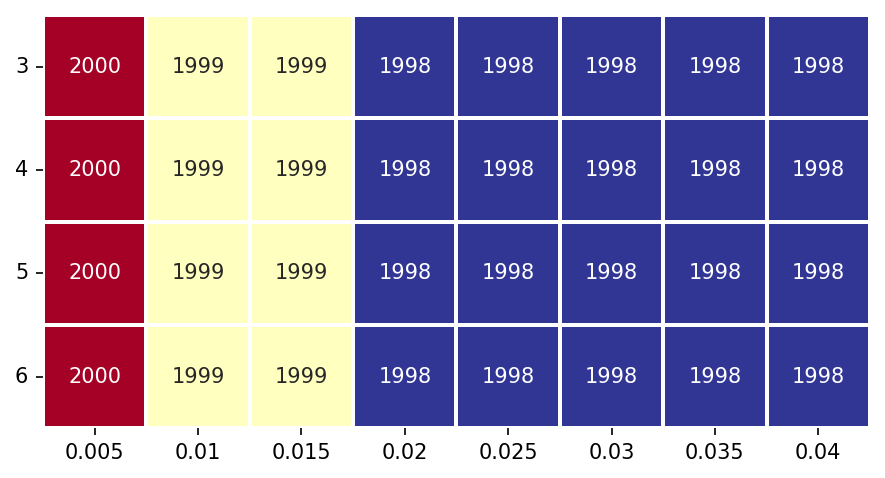

In [5]:
import stage2_phase_funcs as phase_funcs

# Расчет сенситив-анализа
sensitivity_df, sensitivity_dict = phase_funcs.run_phase_sensitivity_analysis(df_long=df_long, region_name="Нижегородская область")

# Визуализация результатов для НО
phase_funcs.plot_sensitivity_heatmap(sensitivity_dict)

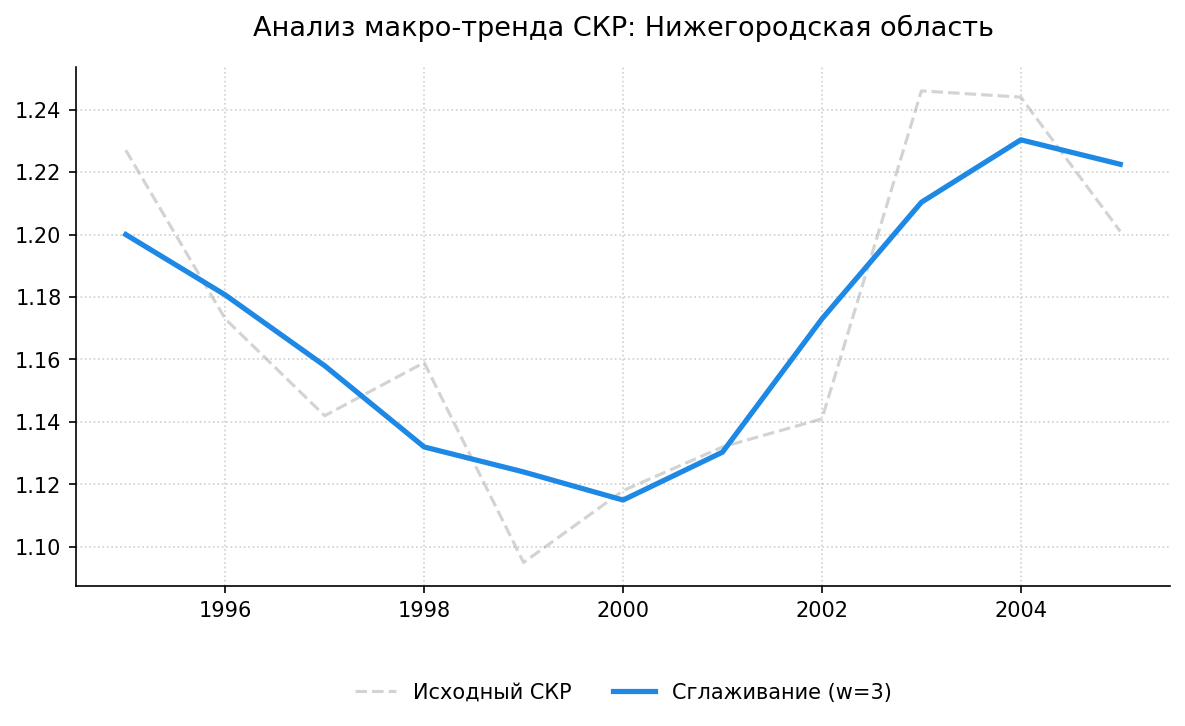

In [6]:
# Визуализация реального и сглаженного СКР для НО (Для сопоставления)
phase_funcs.plot_smoothed_tfr(df_long=df_long, region_name="Нижегородская область", start_year=1995, end_year=2005)

По итогам анализа выбор порога $\epsilon = 0.015$ (допуск на микро-колебания) и окна подтверждения $k=5$ лет является оптимальным с точки зрения баланса между чувствительностью к тренду и помехоустойчивостью.

Выбор параметра $k=5$ лет обусловлен необходимостью сохранения структурной преемственности с оригинальной методологией ООН, где для идентификации завершения фазы снижения используется критерий роста в течение двух последовательных 5-летних периодов. В условиях перехода на годовую частоту данных, 5-летнее окно подтверждения является наиболее надежным аналогом, обеспечивающим фильтрацию случайных флуктуаций. Проведенный сенситив-анализ подтверждает, что данное значение находится в зоне полной устойчивости оценки: вариация окна подтверждения в диапазоне $k \in $ не приводит к смещению даты перехода, что доказывает робастность выбранного параметра для годового ряда СКР.

Согласно результатам сенситив-анализа, использование порогов $\epsilon \geq 0.02$ приводит к преждевременной фиксации перехода к Фазе III (1998 г.). Визуальный анализ сглаженного временного ряда показывает, что при столь высоком допуске алгоритм классифицирует нисходящую динамику периода 1998–1999 гг. как стагнацию, фактически игнорируя выраженное статистическое снижение СКР в 1999 г.

Порог $\epsilon = 0.015$, напротив, позволяет алгоритму идентифицировать данное снижение как продолжение Фазы II, фиксируя переход к Фазе III (постпереходной стабилизации) только после подтверждения смены тренда в 1999 г. Таким образом, $\epsilon = 0.015$ является верхней границей чувствительности алгоритма, при которой он все еще корректно распознает структурный минимум временного ряда, обеспечивая наиболее обоснованную фиксацию момента перехода.

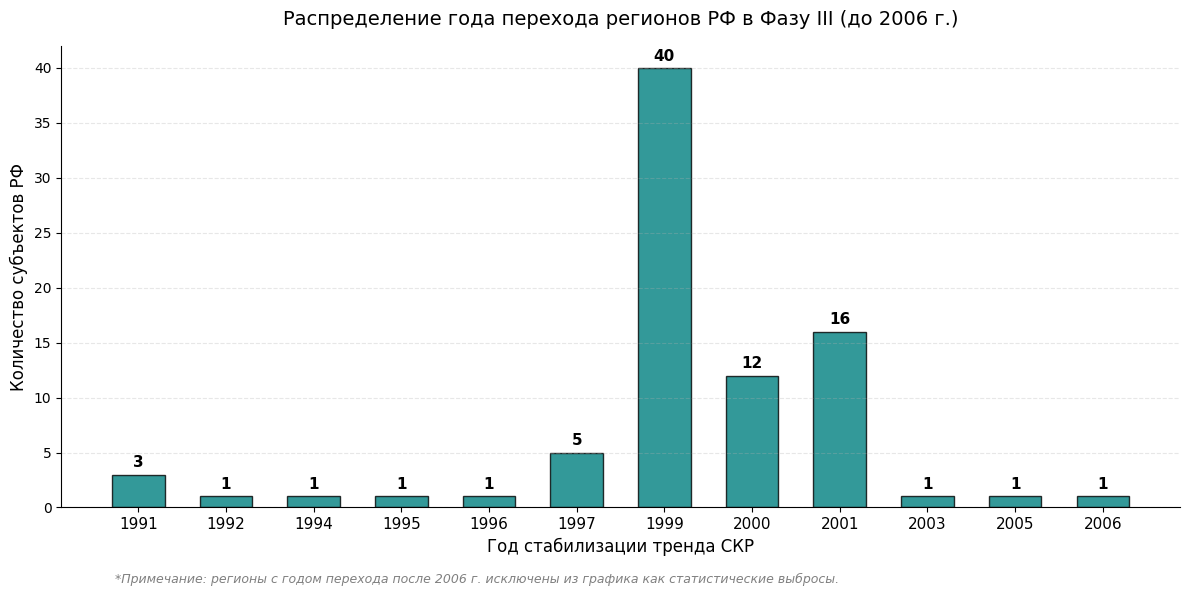

In [8]:
# Назначем фазы перехода с утвержденными параметрами
df_phases, transition_dict = phase_funcs.process_demographic_phases(df_long)

# Визуализируем распределение фаз по годам
phase_funcs.plot_transition_distribution(transition_dict, max_year=2006)

In [9]:
[(k, v) for k, v in transition_dict.items() if v > 2005]

[('Республика Дагестан', 2006)]

### Оценка параметров фазы III

В методологии Alkema et al. СКР в постпереходной стадии моделируется как **AR(1)-процесс**, сходящийся к теоретическому уровню воспроизводства (2.1).

$$
f_{c,t} = \mu + \rho \left(f_{c,t-1} - \mu\right) + e_{c,t}, \quad e_{c,t} \sim \mathcal{N}(0, s^2)
$$

где $\mu = 2.1$ — долгосрочная асимптота модели.

---

**Проблема:** для современной России такая асимптота завышает прогноз, так как не соответствует фактическим демографическим реалиям и ориентирам.

---

**Адаптация модели:** заменяется целевая асимптота  $\mu$ = **2.1 → 1.6**, сохраняя структуру AR(1), но делая прогноз эмпирически согласованным с российской демографической политикой. 

- регионы с $f_{c,t} < 1.6$ → ожидается восстановительный рост  
- регионы с $f_{c,t} > 1.6$ → постепенная конвергенция вниз  

По мере роста урбанизации, уровня образования женщин и их вовлеченности в рынок труда, наблюдается структурное снижение рождаемости, что формирует естественную конвергенцию к среднему целевому уровню. 

http://static.government.ru/media/files/ZsnFICpxWknEXeTfQdmcFHNei2FhcR0A.pdf

---

Следовательно, остаётся оценить два параметра на исторических данных:

- $\rho$ интерпретируется как доля разрыва до $\mu_{target}$, устраняемая за один период - оценивается через МНК без константы
- $s$ рассчитывается как стандартное отклонение остатков регрессии

---

Используя оценённые параметры $\rho$ и $s$, реализуется прогноз:

- старт: фактический СКР (2025)  
- генерируется 10 000 траекторий на 3 года вперёд  
- на каждом шаге добавляется шум:
$$
e_{c,t} \sim \mathcal{N}(0, s^2)
$$

→ результат: контрфактическое распределение СКР без учёта демографической политики

In [12]:
import stage2_forecast_funcs as forecast_funcs

params = forecast_funcs.calculate_baseline_parameters(df_phases, transition_dict)

### Построение прогноза

In [14]:
# Задаем параметры
AR1config = forecast_funcs.AR1Config(
    target_tfr=1.6,     # ← задаём сразу при создании
    n_sims=10_000,      # ← количество симуляций
    random_seed=42      # ← воспроизводимость
)

nizh_obl_forecast, nizh_obl_ensemble = forecast_funcs.simulate_baseline_forecast(
    start_tfr=1.287,      # Факт 2025 года
    params=params,        
    start_year=2025,
    n_years=5,
    config=AR1config
)

print(nizh_obl_forecast)

   Year  Baseline_Median  Baseline_Lower_95  Baseline_Upper_95
0  2026         1.306794           1.116117           1.499696
1  2027         1.329126           1.069613           1.594564
2  2028         1.347385           1.049092           1.662971
3  2029         1.364216           1.024932           1.714006
4  2030         1.377129           1.002690           1.751126


### Оценка адекватности прогноза

Оценка надежности модели основана на концепции статистической калибровки, согласно которой прогностическое распределение должно согласовываться с эмпирической частотой реализации наблюдаемого показателя. В соответствии с подходом Alkema et al. (2011), модель считается хорошо откалиброванной, если доля фактических наблюдений, выходящих за пределы заданных доверительных интервалов, соответствует их номинальным вероятностям (например, около 5% для 95%-го интервала).

В рамках настоящего исследования используется двухэтапная процедура диагностической валидации прогнозной модели.

Первый этап — __тест на систематическое смещение (Bias Test)__. Он основан на сравнении фактических значений с медианой прогнозного распределения. Пусть $\hat{y}_t^{(0.5)}$ обозначает медианный прогноз, тогда оценивается доля наблюдений, для которых:
$$
y_t > \hat{y}_t^{(0.5)}
$$

В идеальном случае эта доля должна быть близка к $0.5$. Существенное отклонение от этого значения интерпретируется как наличие систематического смещения модели, отражающего либо устойчивое завышение, либо занижение прогнозов.

Второй этап — __тест калибровки интервалов (Calibration / Coverage Test)__. Он заключается в оценке частоты попадания фактических значений в доверительные интервалы заданного уровня. Для интервалов уровня $\alpha \in \{0.80, 0.95\}$ вычисляется эмпирическая доля наблюдений, удовлетворяющих условию:
$$
y_t \in \left[\hat{y}_t^{(\alpha/2)}, \hat{y}_t^{(1-\alpha/2)}\right]
$$

Сравнение фактического покрытия с номинальным уровнем позволяет интерпретировать свойства прогнозного распределения: превышение номинального покрытия указывает на избыточную консервативность модели (переоценку неопределенности), тогда как его снижение свидетельствует о недооценке волатильности процесса.

В совокупности данный подход смещает фокус с минимизации точечной ошибки на оценку корректности вероятностного описания процесса. Это особенно важно в условиях демографической динамики, где ключевое значение имеет не только средний прогноз, но и адекватное представление неопределенности, используемое при принятии управленческих решений.

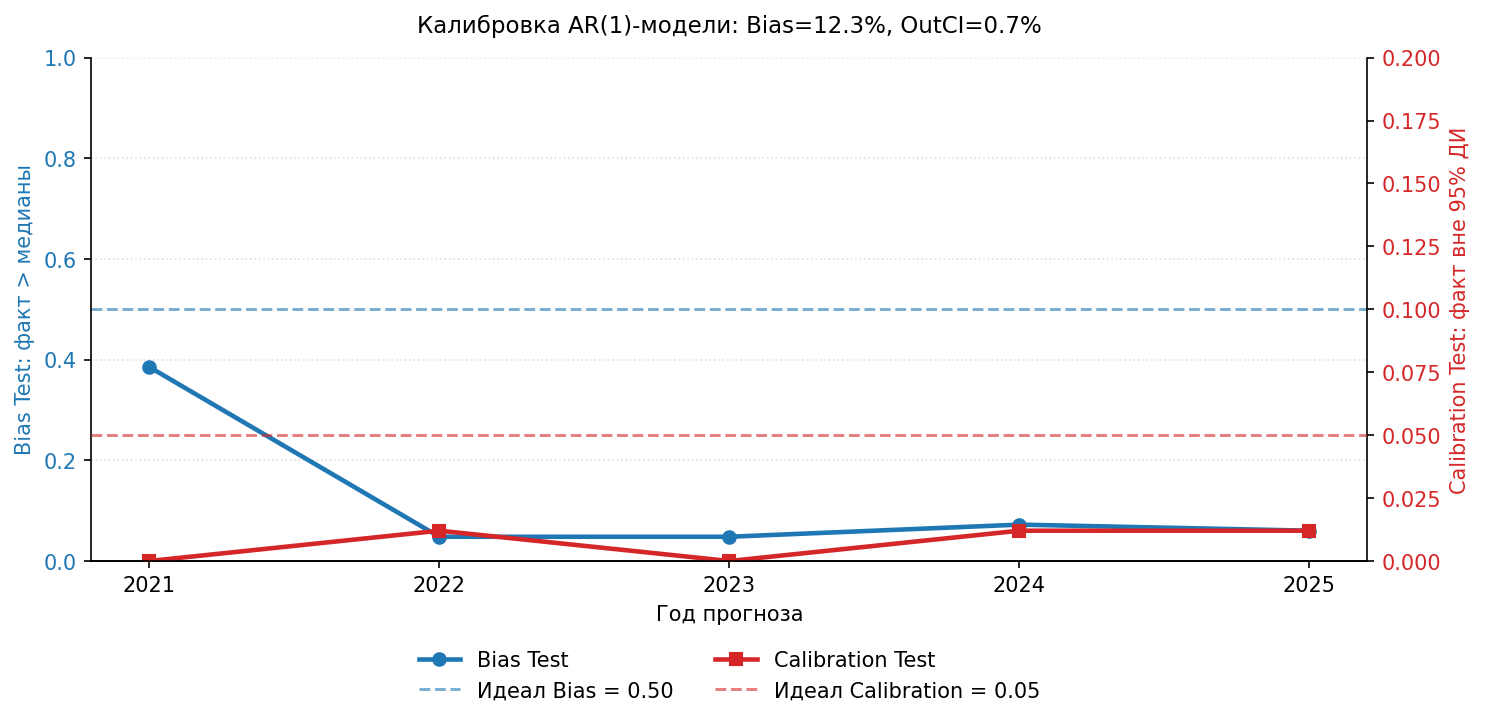

In [17]:
# Конфиг бэктеста
backtest_config = forecast_funcs.BacktestConfig(
    cutoff_year=2020,
    n_forecast_years=5,
)

# Бэктест
backtest_results = forecast_funcs.run_backtest(
    df_long=df_phases,
    transition_dict=transition_dict,
    ar1_config=AR1config,
    backtest_config=backtest_config,
)

# Оценка калибровки
evaluation_results = forecast_funcs.evaluate_calibration(
    backtest_df=backtest_results,
    df_long=df_phases,
)

# График
forecast_funcs.plot_validation_metrics(evaluation_results)

### Решение проблемы смещения

Проблема систематического смещения связана не с самим подходом Alkema, а с его исходным допущением о __едином центре возврата__ для всех единиц наблюдения. В оригинальной модели post-transition динамика СКР описывается как возврат к фиксированному уровню (≈2.1), одинаковому для всех стран, при оценке параметров на объединённых данных.

Для российской региональной панели это допущение оказывается слишком жёстким: устойчивые межрегиональные различия в уровне рождаемости не сводятся к случайным отклонениям вокруг одной общей асимптоты. В результате использование единого центра приводит к систематическому смещению — завышению прогнозов для низкофертильных регионов и занижению для высокофертильных. 

Решение заключается в __региональной адаптации__ модели при сохранении её базовой структуры. Логика AR(1)-динамики Phase III полностью сохраняется, однако единый центр возврата заменяется на регионально-специфический:
$$
\mu_r = \mu_{RU} + \alpha_r
$$

где $\mu_{RU}$ — федеральный ориентир, а $\alpha_r$ — региональная поправка.

Динамика СКР задаётся как:
$$
f_{r,t+1} = f_{r,t} + \rho(\mu_r - f_{r,t}) + \varepsilon_{r,t}
$$

Оценка $\alpha_r$ осуществляется в рамках __двухэтапной процедуры__. На первом этапе на объединённой панели данных Фазы III оценивается общий параметр возврата:
$$
f_{r,t+1} - f_{r,t} = \rho(\mu_{RU} - f_{r,t}) + e_{r,t}
$$

Полученная оценка $\hat{\rho}$ отражает среднюю скорость возврата к федеральному ориентиру по всем регионам.

На втором этапе анализируются остатки модели:
$$
\hat{e}_{r,t} = (f_{r,t+1} - f_{r,t}) - \hat{\rho}(\mu_{RU} - f_{r,t})
$$

Если регион систематически отклоняется от федерального уровня, среднее значение остатков по времени будет отличаться от нуля. Это отклонение интерпретируется как проявление регионального сдвига центра, и используется для оценки поправки:
$$
\hat{\alpha}_r = \frac{1}{\hat{\rho}} \cdot \frac{1}{T_r} \sum_{t} \hat{e}_{r,t}
$$

где $T_r$ — число наблюдений региона в Фазе III.

Таким образом, параметр $\rho$ захватывает __общую динамику процесса__, оцененную по всей панели, тогда как $\alpha_r$ отражает __устойчивое региональное отклонение__ от федерального ориентира.

Такая спецификация позволяет одновременно:
- сохранить связь с официальным демографическим ориентиром;
- учесть межрегиональную неоднородность;
- устранить систематическое смещение прогнозов.

В результате модель приобретает __иерархическую структуру__, где общий тренд задаётся на федеральном уровне, а долгосрочные уровни адаптируются под региональную специфику.

In [20]:
import stage2_forecast_funcs_adjusted as forecast_adj_funcs

# 1. Настройка с учетом федеральной цели
h_config = forecast_adj_funcs.HierarchicalConfig(federal_target=AR1config.target_tfr)

# 2. Оценка параметров (оцениваются ρ и все α_r)
params = forecast_adj_funcs.estimate_hierarchical_params(df_long, transition_dict, config=h_config)

# 3. Бэктест (прогноз для всех регионов по иерархической модели)
bt_config = forecast_adj_funcs.BacktestConfig(cutoff_year=2020, n_forecast_years=5)
backtest_results = forecast_adj_funcs.run_hierarchical_backtest(df_long, transition_dict, h_config, bt_config)

# 4. Проверка калибровки (Bias должен стать ближе к 0.5)
calib = forecast_adj_funcs.evaluate_hierarchical_calibration(backtest_results, df_long)

# 5. Прогон для верификации различных спецификаций
df_period_compare = forecast_adj_funcs.run_hierarchical_period_comparison(
    df_long=df_long, transition_dict=transition_dict, federal_target=AR1config.target_tfr,
    cutoff_years=[2010, 2015, 2020], n_forecast_years=5,
)

# Таблица с результатами теста смещений bias и calibration
df_period_compare.head()

,cutoff_year,n_forecast_years,rho,s,n_obs,bias,error
0,2010,5,0.107058,0.107565,890,0.843373,0.024096
1,2015,5,0.076828,0.100545,1300,0.040964,0.279518
2,2020,5,0.081867,0.101430,1710,0.060241,0.043373


In [56]:
params.attractors.alpha['Нижегородская область']

np.float64(-0.1244834393126259)

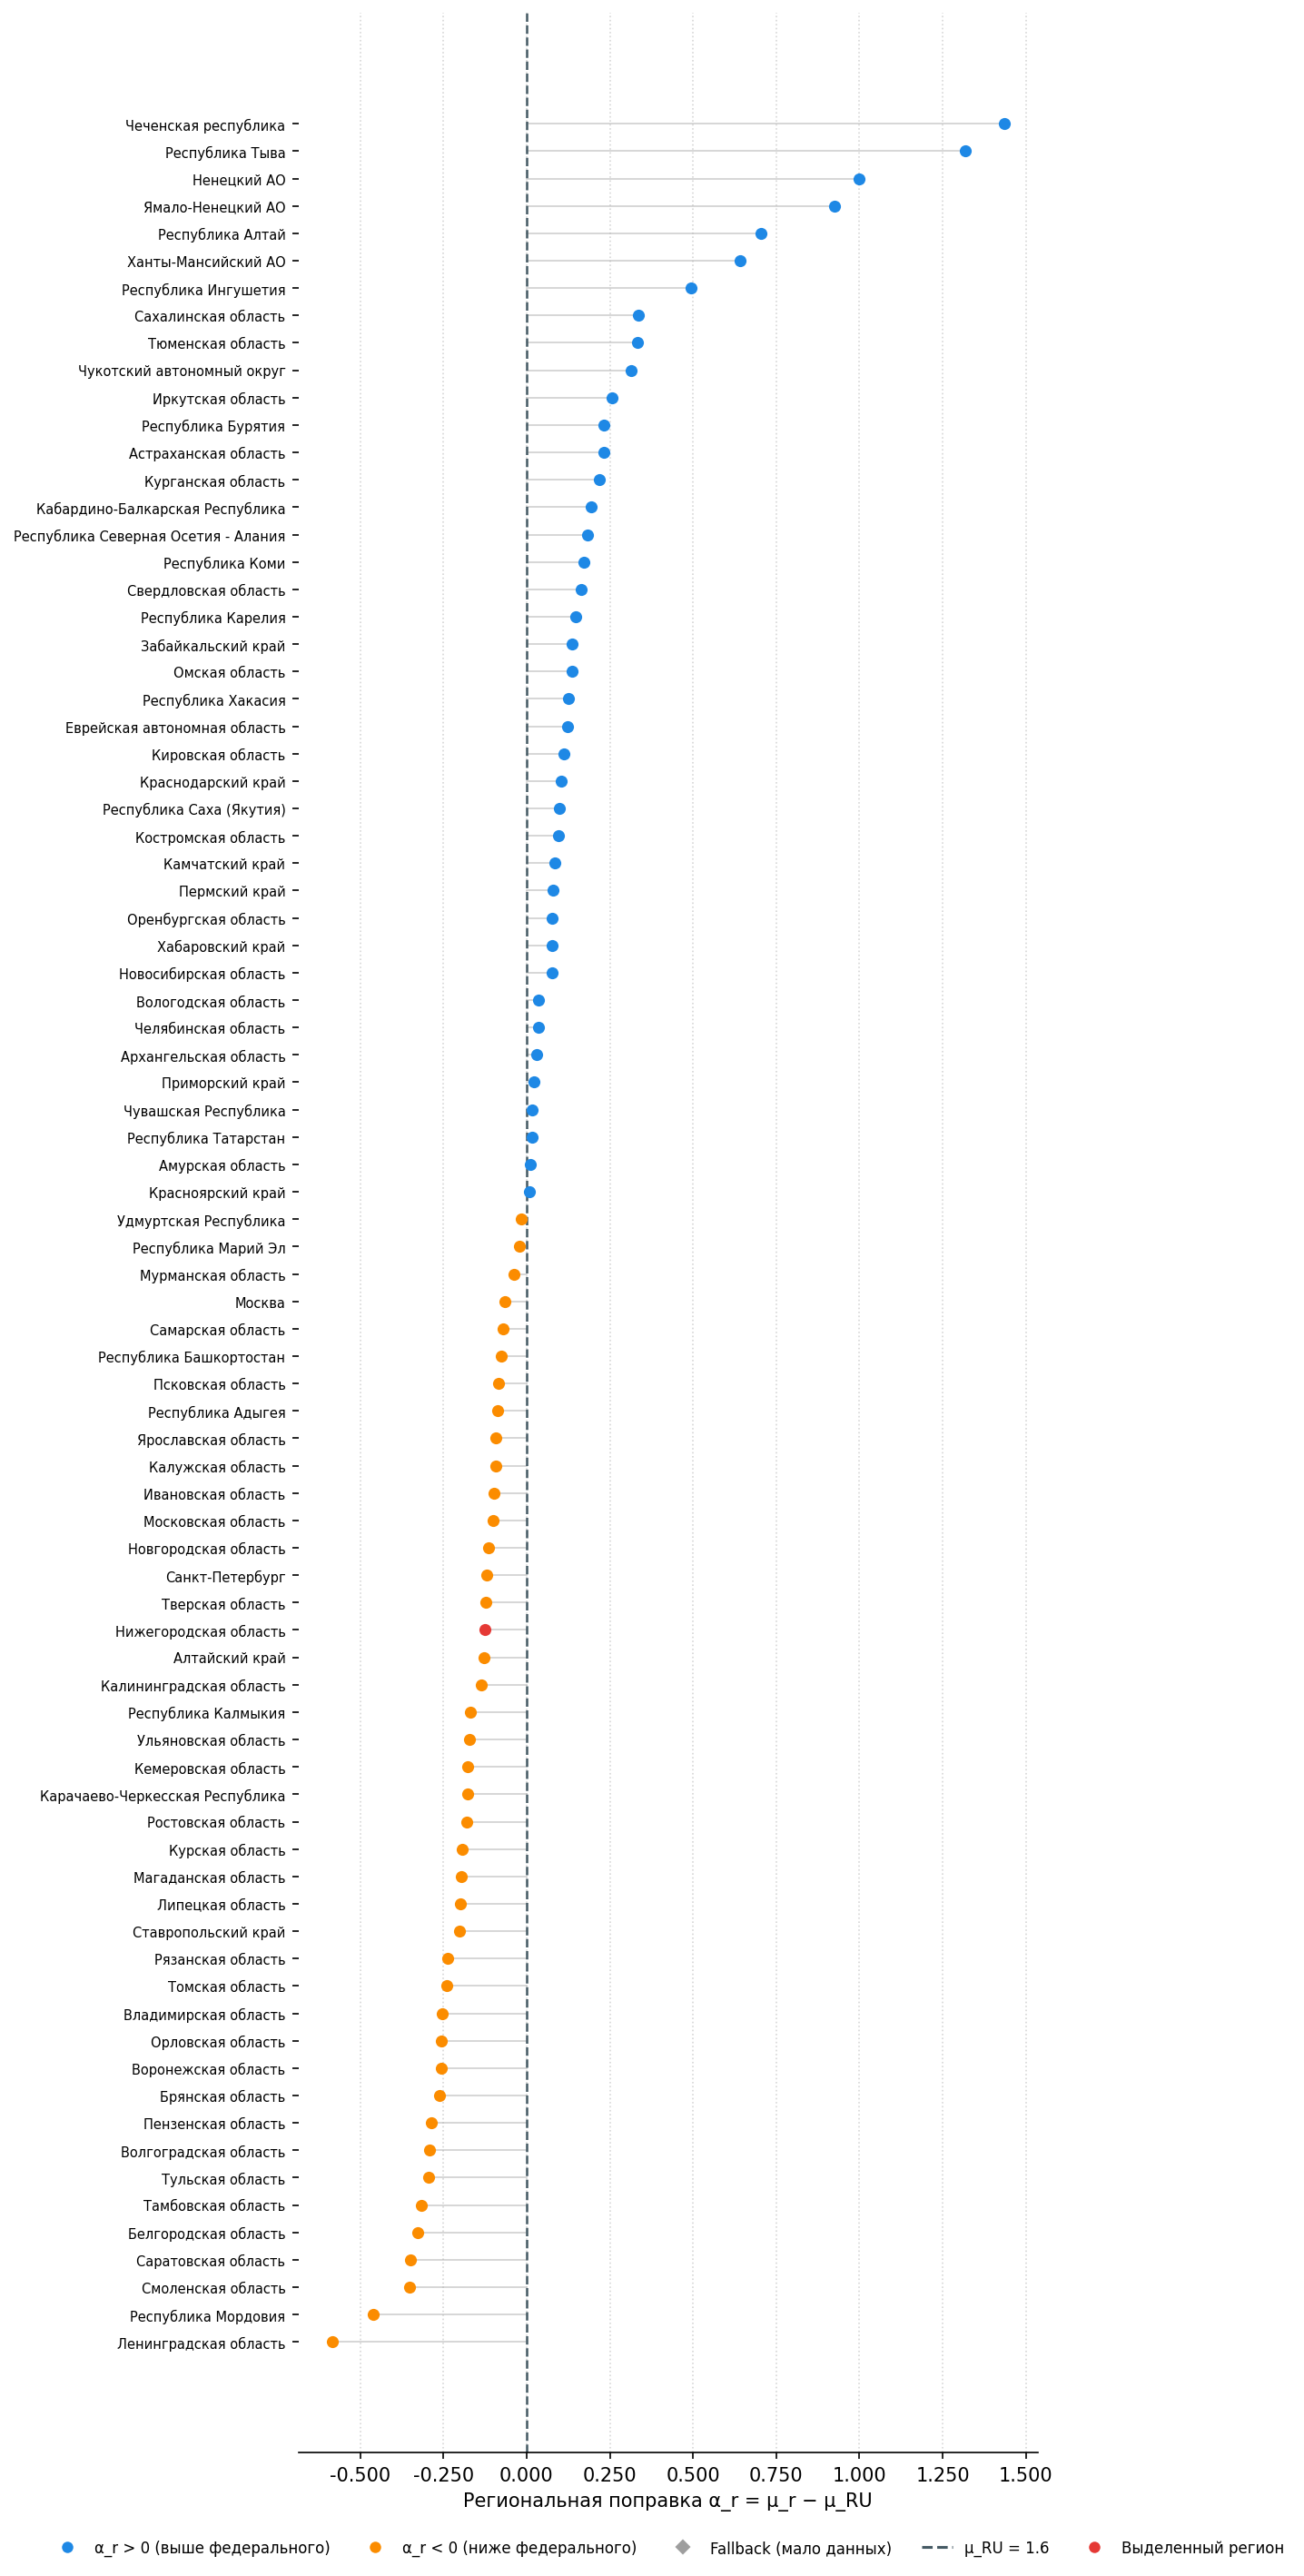

In [21]:
# 5. Визуализация: α_r для каждого региона
forecast_adj_funcs.plot_regional_attractors(params.attractors, highlight=["Нижегородская область"])

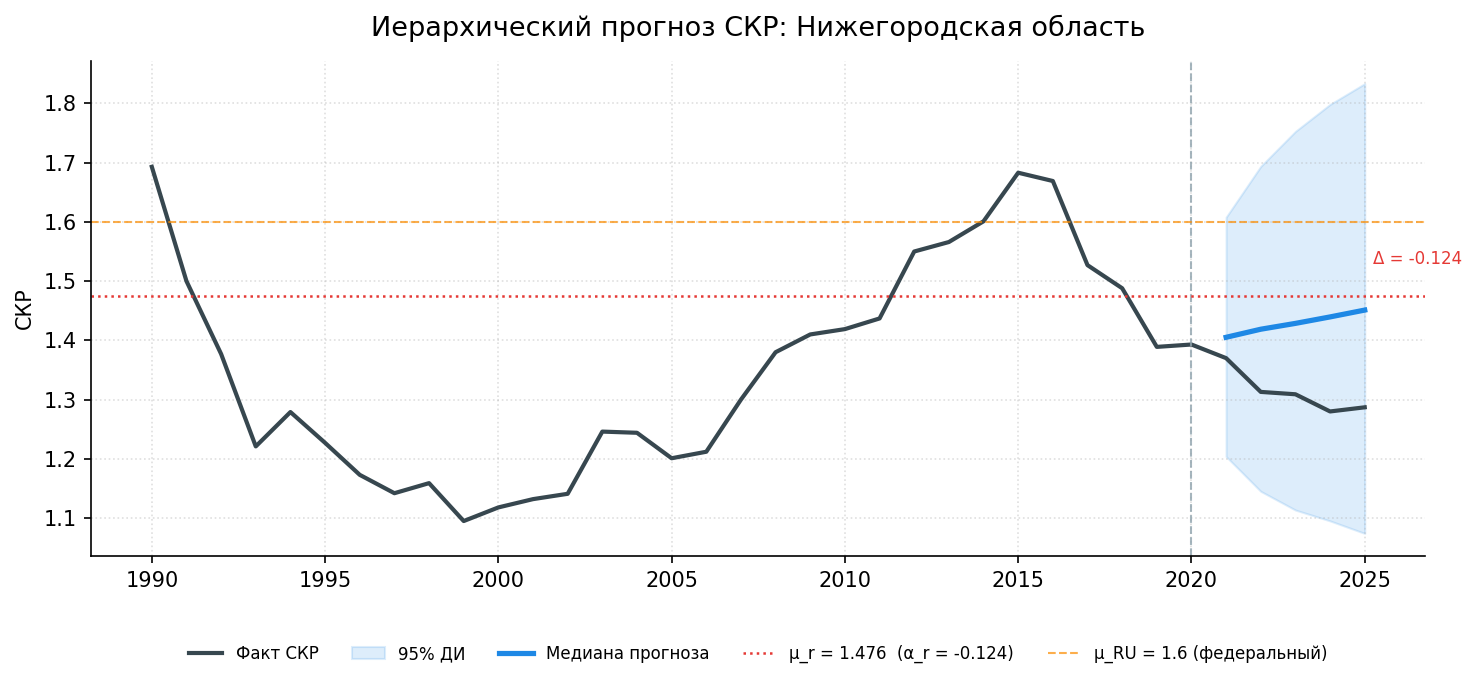

In [22]:
# 6. Визуализация: прогноз конкретного региона
nizh_forecast = backtest_results[backtest_results["Регион"] == "Нижегородская область"]
forecast_adj_funcs.plot_regional_forecast(nizh_forecast, df_long, "Нижегородская область", params.attractors, 2020)

Бэктестинг иерархической AR(1)-модели с региональными поправками выявил чувствительность метрик качества к выбору обучающего окна, что отражает нестационарность демографической динамики, а не недостатки алгоритма.

Результаты для различных отсечек подтверждают этот вывод. Спецификация с `cutoff_year = 2010` (прогноз на 2011–2015 гг.) демонстрирует значительное смещение (Bias = 0.843): фактическая рождаемость росла быстрее, чем предполагала инерционная динамика модели. При `cutoff_year = 2015` (прогноз на 2016–2020 гг.) наблюдается резкое ухудшение калибровки интервалов (Error = 0.280), что связано с переходом от роста к устойчивому снижению СКР. Спецификация с `cutoff_year = 2020` достигла хорошей интервальной калибровки (Error = 0.043) при сильном смещении медианы (Bias = 0.060). Это указывает на корректную оценку неопределённости при некоторой переоценке возврата к долгосрочному уровню.

Таким образом, наблюдаемые отклонения качества прогноза обусловлены структурными переломами тренда, а не спецификацией модели. В условиях текущего демографического режима, характеризующегося стабилизацией постпереходной динамики, подход признается релевантным для целей среднесрочного прогнозирования (Хотя бы в рамках ВКР).

В дальнейшем данный подход используется как __инерционный контрфактический сценарий__, отражающий базовую траекторию рождаемости без дополнительного вмешательства и служащий основой для оценки эффектов демографической политики.

### Итоговый прогноз

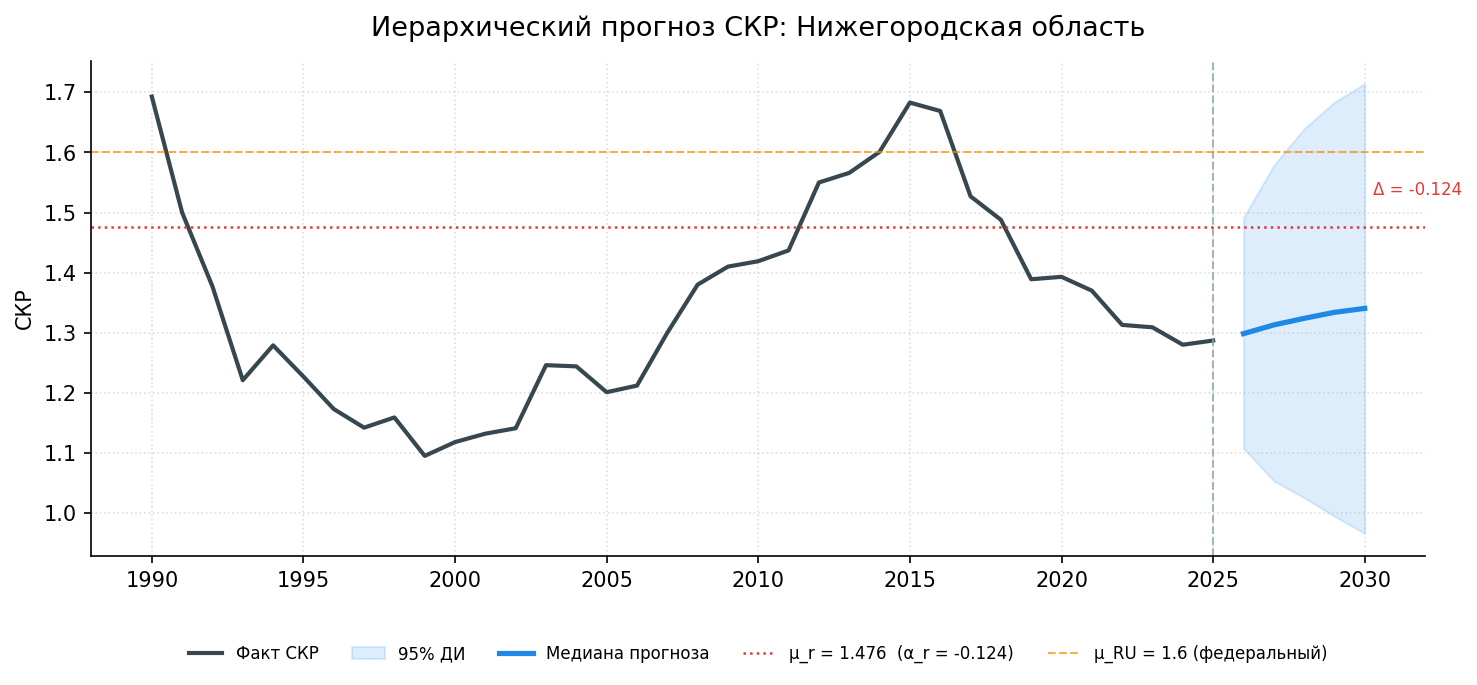

In [25]:
# Мы передаем params, которые получили на этапе estimate_hierarchical_params
nizh_forecast_future, ensemble = forecast_adj_funcs.simulate_regional_forecast(
    region="Нижегородская область",
    start_tfr=1.287,
    start_year=2025,
    n_years=5,
    params=params,  
    config=h_config
)

# Визуализация прогноза
forecast_adj_funcs.plot_regional_forecast(
    df_forecast=nizh_forecast_future,
    df_history=df_long,
    region="Нижегородская область",
    attractors=params.attractors,
    start_year=2025
)

In [26]:
import numpy as np

# Имя файла
filename = "nizh_forecast_ensemble.csv"

# Конвертируем в DataFrame
years = np.arange(2026, 2031)
df_ensemble = pd.DataFrame(ensemble, columns=[f"year_{y}" for y in years])

# Сохраняем в csv
df_ensemble.to_csv(filename, index=False)

# Вывод таблицы (чтобы посмотреть цифры)
print(nizh_forecast_future)

   Year    Median  Lower_95  Upper_95      mu_r
0  2026  1.298412  1.107735  1.491314  1.475517
1  2027  1.312927  1.053413  1.578365  1.475517
2  2028  1.323895  1.025602  1.639481  1.475517
3  2029  1.333925  0.994641  1.683716  1.475517
4  2030  1.340496  0.966057  1.714493  1.475517
